In [1]:
# Load libraries
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Setting working directory
os.chdir("//wsl.localhost/Ubuntu/home/aaslam123/SummerSchool2026/Module2/Project_scRNA+Report")

In [ ]:
# Reading the sample information
sampleinfo = pd.read_csv("sampleinfo_project.csv")
sampleinfo

,SampleName,type
0,Normal,Illumina HiSeq 4000
1,Leukemia,Illumina HiSeq 4000


In [4]:
# Read 10X data (per sample) — each SampleName must match a folder name
adatas = []

for sample in sampleinfo["SampleName"]:
    adata = sc.read_10x_mtx(
        sample,
        var_names="gene_symbols",
        cache=False
    )
    adata.obs["sample"] = sample
    adatas.append(adata)
    
    print(f"{sample}: {adata.shape}")


Normal: (760, 36601)
Leukemia: (971, 36601)


In [5]:
print(adatas)

[AnnData object with n_obs × n_vars = 760 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
    layers: None (.X), AnnData object with n_obs × n_vars = 971 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
    layers: None (.X)]


In [ ]:
# Merge samples into one object,
for adata, sample in zip(adatas, sampleinfo["SampleName"]):
    adata.obs_names = [f"{sample}_{bc}" for bc in adata.obs_names]

adata = ad.concat(
    adatas,
    join="outer",
    label="sample_id",
    keys=sampleinfo["SampleName"]
)


In [ ]:
# Attach condition to every cell
adata.obs = adata.obs.merge(
    sampleinfo[["SampleName", "type"]],
    left_on="sample", right_on="SampleName", how="left"
).set_index(adata.obs.index)

print(adata)  
adata.obs.to_csv("result_datasets/cell_metadata_raw.csv")

AnnData object with n_obs × n_vars = 1731 × 36601
    obs: 'sample', 'sample_id', 'SampleName', 'type'
    layers: None (.X)


In [8]:
### Quality control metrics ###
# Number of genes per cell (0, gene absent, non zero, gene present)
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
adata.obs["n_genes"].head()

Normal_AAACCTGAGGACCACA-1    2292
Normal_AAACCTGGTTTGGGCC-1    2133
Normal_AAACGGGAGCAATATG-1    4722
Normal_AAACGGGCATGTCTCC-1    2589
Normal_AAACGGGTCGCGCCAA-1    2151
Name: n_genes, dtype: int64

In [9]:
# Compute basic QC metrics
# Total counts/UMIs per cell
adata.obs["n_counts"] = adata.X.sum(axis=1).A1 # Cell_1: gene1 + gene2 + ... + gene56941 = total UMIs counts
adata.obs["n_counts"].head()

Normal_AAACCTGAGGACCACA-1     7579.0
Normal_AAACCTGGTTTGGGCC-1     8487.0
Normal_AAACGGGAGCAATATG-1    19622.0
Normal_AAACGGGCATGTCTCC-1     8433.0
Normal_AAACGGGTCGCGCCAA-1     7696.0
Name: n_counts, dtype: float32

In [10]:
# Average counts per gene
adata.obs["counts_per_gene"] = adata.obs["n_counts"] / adata.obs["n_genes"]
adata.obs["counts_per_gene"].head()

Normal_AAACCTGAGGACCACA-1    3.306719
Normal_AAACCTGGTTTGGGCC-1    3.978903
Normal_AAACGGGAGCAATATG-1    4.155443
Normal_AAACGGGCATGTCTCC-1    3.257242
Normal_AAACGGGTCGCGCCAA-1    3.577871
Name: counts_per_gene, dtype: float64

In [11]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-")) # human mito genes
print("Mito genes found:", adata.var["mt"].sum())

Mito genes found: 13


In [12]:
# Identify ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
print("Ribo genes found:", adata.var["ribo"].sum())

Ribo genes found: 103


In [ ]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True
)

adata.obs.to_csv("result_datasets/QC_raw_table.csv")

In [14]:
# Check head of obs DataFrame to see the new QC metrics
adata.obs.head()

,sample,sample_id,SampleName,type,n_genes,n_counts,counts_per_gene,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
Normal_AAACCTGAGGACCACA-1,Normal,Normal,Normal,Illumina HiSeq 4000,2292,7579.0,3.306719,2292,7579.0,139.0,1.834015,3396.0,44.808022
Normal_AAACCTGGTTTGGGCC-1,Normal,Normal,Normal,Illumina HiSeq 4000,2133,8487.0,3.978903,2133,8487.0,174.0,2.050194,4293.0,50.583244
Normal_AAACGGGAGCAATATG-1,Normal,Normal,Normal,Illumina HiSeq 4000,4722,19622.0,4.155443,4722,19622.0,705.0,3.592906,5947.0,30.307817
Normal_AAACGGGCATGTCTCC-1,Normal,Normal,Normal,Illumina HiSeq 4000,2589,8433.0,3.257242,2589,8433.0,130.0,1.541563,3678.0,43.614372
Normal_AAACGGGTCGCGCCAA-1,Normal,Normal,Normal,Illumina HiSeq 4000,2151,7696.0,3.577871,2151,7696.0,99.0,1.286383,3653.0,47.466217


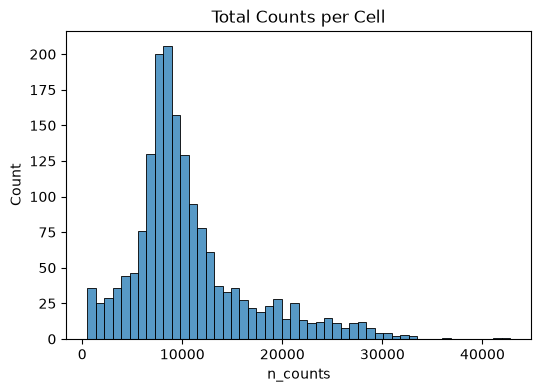

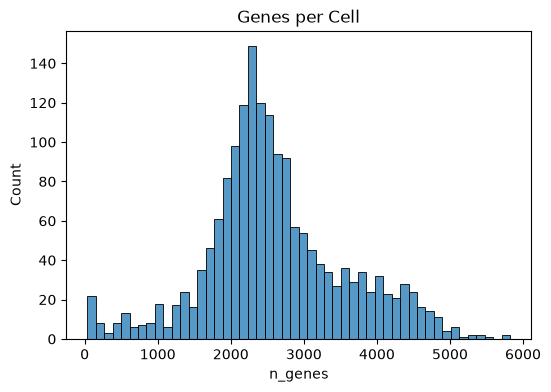

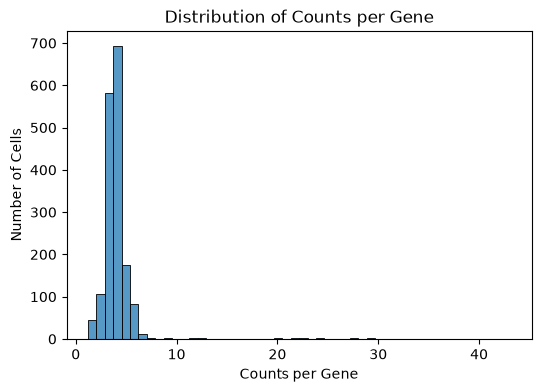

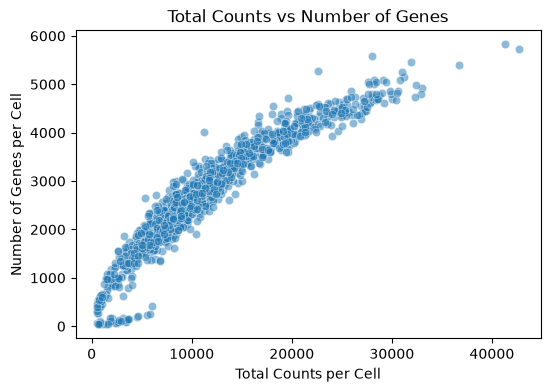

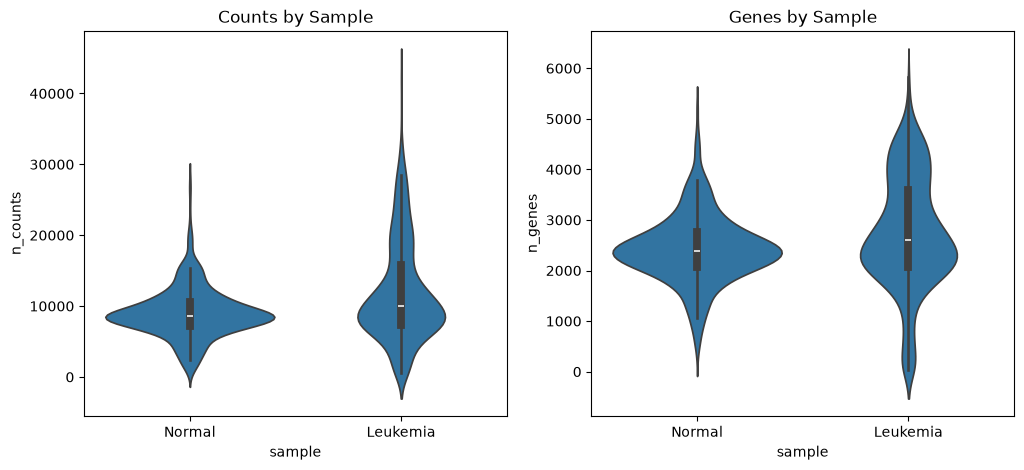

In [15]:
# Histogram of total counts per cell
plt.figure(figsize=(6,4)); sns.histplot(adata.obs["n_counts"], bins=50); plt.title("Total Counts per Cell"); plt.show()

# Histogram of number of genes per cell
plt.figure(figsize=(6,4)); sns.histplot(adata.obs["n_genes"], bins=50); plt.title("Genes per Cell"); plt.show()

# Histogram of counts per gene
plt.figure(figsize=(6, 4)); sns.histplot(adata.obs["counts_per_gene"], bins=50, kde=False); plt.xlabel("Counts per Gene")
plt.ylabel("Number of Cells")
plt.title("Distribution of Counts per Gene")
plt.show()

# Scatter plot of total counts vs number of genes
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata.obs, alpha=0.5)
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes")
plt.show()

# Make voilen plot of n_counts per sample & n_genes per sample
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.violinplot(x="sample", y="n_counts", data=adata.obs); plt.title("Counts by Sample")
plt.subplot(1,2,2); sns.violinplot(x="sample", y="n_genes", data=adata.obs); plt.title("Genes by Sample")
plt.show()

In [16]:
# Check quantiles
adata.obs["n_counts"].quantile([0.01, 0.99])

0.01      805.2
0.99    29346.8
Name: n_counts, dtype: float64

In [17]:
# Check quantiles
adata.obs["n_genes"].quantile([0.01, 0.99])


0.01     117.3
0.99    4900.1
Name: n_genes, dtype: float64

In [18]:
# Check quantiles
adata.obs["counts_per_gene"].quantile([0.01, 0.99])

0.01     1.573973
0.99    20.221891
Name: counts_per_gene, dtype: float64

In [ ]:
## Compute quantile thresholds
n_counts_low, n_counts_high = adata.obs["n_counts"].quantile([0.01, 0.99])
n_genes_low, n_genes_high = adata.obs["n_genes"].quantile([0.01, 0.99])
complex_low, complex_high = adata.obs["counts_per_gene"].quantile([0.01, 0.99])

# Define mito and ribo thresholds 
mito_threshold = 15
ribo_threshold = 60   ## 40 WAS TOO STRINGENT, LEADING TO ONLY 323 CELLS REMAINING

# Apply all filters together
adata_filtered = adata[
    (adata.obs["n_counts"] >= n_counts_low) & (adata.obs["n_counts"] <= n_counts_high) &
    (adata.obs["n_genes"] >= n_genes_low) & (adata.obs["n_genes"] <= n_genes_high) &
    (adata.obs["counts_per_gene"] >= complex_low) & (adata.obs["counts_per_gene"] <= complex_high) &
    (adata.obs["pct_counts_mt"] < mito_threshold) &
    (adata.obs["pct_counts_ribo"] < ribo_threshold),
    :
].copy()

print("Cells before:", adata.n_obs, "| after:", adata_filtered.n_obs)
adata_filtered.obs.to_csv("result_datasets/QC_filtered_table.csv")

Cells before: 1731 | after: 1643


In [20]:
adata_filtered.shape

(1643, 36601)

In [21]:
adata.shape

(1731, 36601)

Text(0.5, 1.0, 'Number of Genes per Cell by Sample (Filtered)')

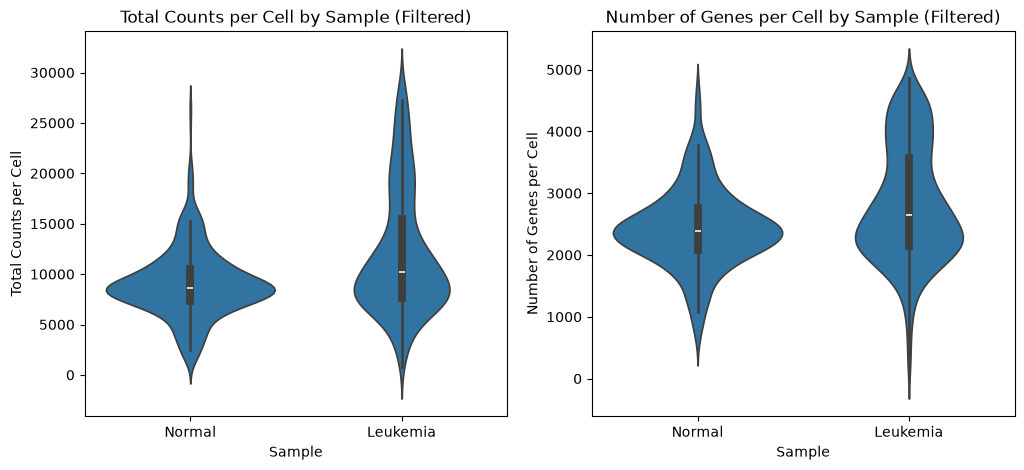

In [22]:
# make voilen plot of n_counts per sample & n_genes per sample after filtering
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x="sample", y="n_counts", data=adata_filtered.obs)
plt.xlabel("Sample")
plt.ylabel("Total Counts per Cell")
plt.title("Total Counts per Cell by Sample (Filtered)")

plt.subplot(1, 2, 2)
sns.violinplot(x="sample", y="n_genes", data=adata_filtered.obs)
plt.xlabel("Sample")
plt.ylabel("Number of Genes per Cell")
plt.title("Number of Genes per Cell by Sample (Filtered)")

In [23]:
adata_filtered.shape

(1643, 36601)

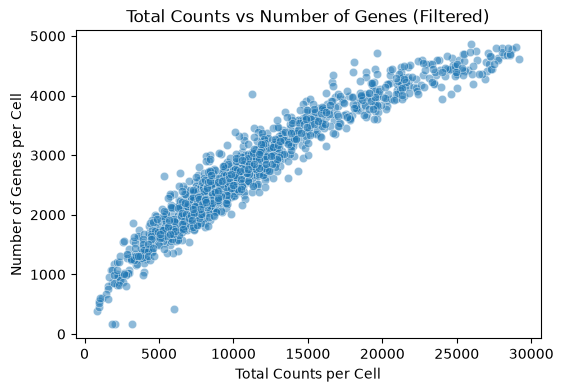

In [24]:
# scatter plot of total counts vs number of genes after filtering
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata_filtered.obs, alpha=0.5)
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes (Filtered)")
plt.show()

In [25]:
# Freeze raw counts after QC filtering
adata_filtered.raw = adata_filtered.copy()

In [26]:
# Normalize counts (library-size normalization)
sc.pp.normalize_total(adata_filtered, target_sum=1e4)

# Log transform normalized data
sc.pp.log1p(adata_filtered)

# Preserve log-normalized expression
adata_filtered.layers["lognorm"] = adata_filtered.X.copy()

In [27]:
# Total counts per cell (raw)
adata_filtered.obs["total_counts_raw"] = (
    adata_filtered.raw.X.sum(axis=1).A1
)

# Total counts per cell (normalized)
adata_filtered.obs["total_counts_normalized"] = (
    adata_filtered.X.sum(axis=1).A1
)
# Check the first few rows of obs to see the new total counts columns
adata_filtered.obs[["total_counts_raw", "total_counts_normalized"]].head()

,total_counts_raw,total_counts_normalized
Normal_AAACCTGAGGACCACA-1,7579.0,2664.810059
Normal_AAACCTGGTTTGGGCC-1,8487.0,2343.443604
Normal_AAACGGGAGCAATATG-1,19622.0,3605.715576
Normal_AAACGGGCATGTCTCC-1,8433.0,2803.073486
Normal_AAACGGGTCGCGCCAA-1,7696.0,2481.897217


In [ ]:
# Identify highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata_filtered, flavor="seurat", n_top_genes=2000)
adata_filtered.var.to_csv("result_datasets/HVG_statistics_full.csv")

# Check the first few rows of var to see the new highly variable gene columns
adata_filtered.var.head()

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
MIR1302-2HG,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
FAM138A,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
OR4F5,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
AL627309.1,False,False,2,0.001155,99.88446,2.0,False,5.509089e-04,-0.787474,-2.523304
AL627309.3,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN


In [29]:
# Chaeck the number of rows and columns in the adata_filtered.var DataFrame
adata_filtered.var.shape

(36601, 10)

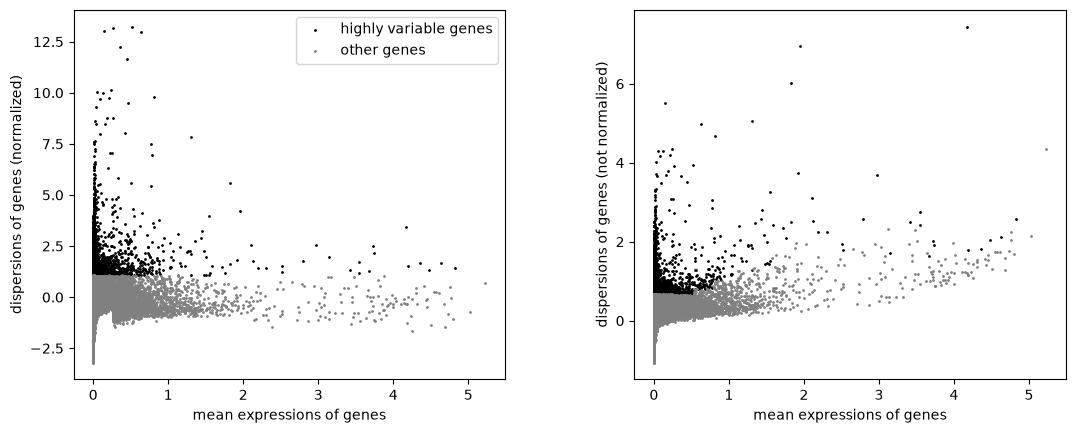

In [30]:
# Visualize highly variable genes in normalized mean vs normalized variance plot
sc.pl.highly_variable_genes(adata_filtered)

In [31]:
# Extract only the highly variable genes
hvg_only = adata_filtered.var[
    adata_filtered.var["highly_variable"]
]
hvg_only.head()

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC00115,False,False,10,0.005777,99.422299,10.0,True,0.008986,1.077880,2.076110
AL645608.6,False,False,6,0.004044,99.653380,7.0,True,0.004616,1.026355,1.949066
SAMD11,False,False,4,0.002311,99.768920,4.0,True,0.007757,2.107508,4.614870
TNFRSF18,False,False,2,0.001155,99.884460,2.0,True,0.002053,0.862965,1.546193
TNFRSF4,False,False,23,0.015020,98.671288,26.0,True,0.021707,0.892244,1.618386


In [32]:
# number of rows and columns in the hvg_only DataFrame
hvg_only.shape

(2000, 10)

In [ ]:
# Export only the highly variable genes statistics to CSV
hvg_only.to_csv("result_datasets/HVG_statistics_HVGonly.csv")

In [34]:
adata_hvg = adata_filtered[
    :, adata_filtered.var["highly_variable"]
].copy()

In [35]:
# Convert the sparse matrix of highly variable genes to a DataFrame
expr_df = pd.DataFrame(
    adata_hvg.X.toarray(),
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

expr_df.head()


,LINC00115,AL645608.6,SAMD11,TNFRSF18,TNFRSF4,CCDC27,CHD5,UTS2,TNFRSF9,ERRFI1,...,RAP2C-AS1,LINC00629,FHL1,AL683813.1,Z96074.1,FGF13,IL9R,MT-CO1,MT-CO2,MT-ND4L
Normal_AAACCTGAGGACCACA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.525945,3.154034,0.000000
Normal_AAACCTGGTTTGGGCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.201341,3.201341,0.000000
Normal_AAACGGGAGCAATATG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.889888,3.979534,0.411866
Normal_AAACGGGCATGTCTCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.721293,2.723255,0.000000
Normal_AAACGGGTCGCGCCAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.312103,3.246030,0.000000


In [ ]:
# Export the expression matrix of highly variable genes to CSV
expr_df.to_csv("result_datasets/HVG_expression_matrix.csv")

In [37]:
# Shape of matrix with only highly variable genes
adata_hvg.shape

(1643, 2000)

In [38]:
# shape of matrix after QC
adata_filtered.raw.shape

(1643, 36601)

In [39]:
# shape of log-normalized matrix
adata_filtered.layers["lognorm"].shape

(1643, 36601)

In [40]:
# Scale HVGs
sc.pp.scale(adata_hvg, max_value=10)

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
# Check scaled matrix head
scaled_df = pd.DataFrame(
    adata_hvg.X[:10, :10],
    index=adata_hvg.obs_names[:10],
    columns=adata_hvg.var_names[:10]
)
scaled_df

,LINC00115,AL645608.6,SAMD11,TNFRSF18,TNFRSF4,CCDC27,CHD5,UTS2,TNFRSF9,ERRFI1
Normal_AAACCTGAGGACCACA-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAACCTGGTTTGGGCC-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAACGGGAGCAATATG-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAACGGGCATGTCTCC-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAACGGGTCGCGCCAA-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAAGATGGTAGAGTGC-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AAAGATGTCAGCGACC-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AACACGTCACTTCTGC-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AACCGCGAGGGTGTGT-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971
Normal_AACCGCGCAGCGTCCA-1,-0.066754,-0.04877,-0.039258,-0.031597,-0.110082,-0.024671,-0.038992,-0.031708,-0.057295,-0.029971


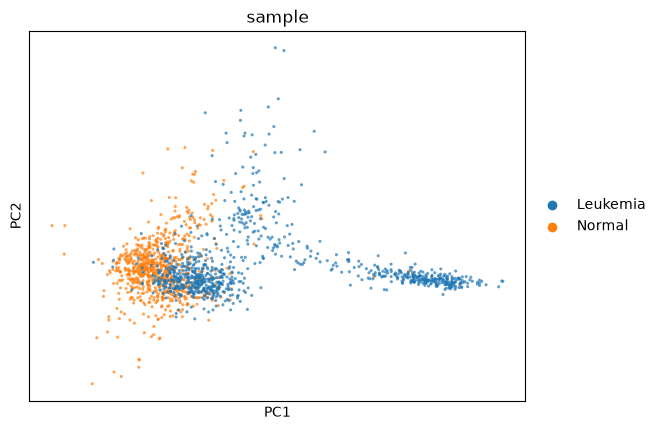

In [42]:
# Principal Component Analysis (PCA)

sc.tl.pca(
    adata_hvg,
    svd_solver="arpack"
)
# Step 2: visualize PCA embedding colored by sample
sc.pl.pca(adata_hvg, color="sample", size=20, alpha=0.7)

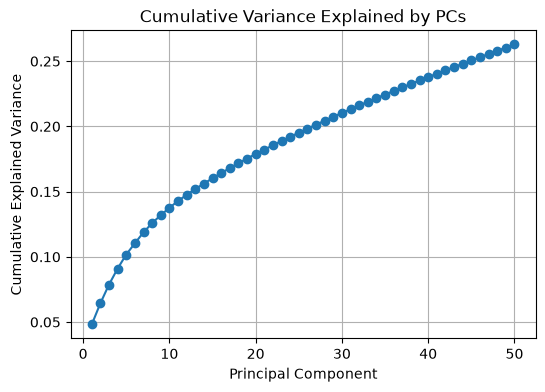

In [43]:
# Step 3: Compare variance captured by first few PCs vs remaining
explained_variance = adata_hvg.uns["pca"]["variance_ratio"]
cumulative_var = explained_variance.cumsum()
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCs")
plt.grid(True)
plt.show()

In [44]:
# Step 5: Inspect gene loadings for PC1

pc1_genes = pd.Series(
    adata_hvg.varm["PCs"][:, 0],  
    index=adata_hvg.var_names
).sort_values(ascending=False)
print("Top 10 genes contributing to PC1:")
print(pc1_genes.head(10))

Top 10 genes contributing to PC1:
HBB        0.120777
APOC1      0.118294
AHSP       0.117626
KLF1       0.115286
BLVRB      0.114860
FAM178B    0.114359
HBA1       0.113883
HBD        0.110614
KCNH2      0.109707
ANK1       0.109149
dtype: float64


In [ ]:
# Step 6: Export PCA coordinates to CSV
pca_coords = pd.DataFrame(
    adata_hvg.obsm["X_pca"],
    index=adata_hvg.obs_names,
    columns=[f"PC{i+1}" for i in range(adata_hvg.obsm["X_pca"].shape[1])]
)
pca_coords.to_csv("result_datasets/PCA_coordinates.csv")

In [46]:
# Step 7: Check how many PCs are needed to cover 80% of variance
n_pcs_80 = sum(cumulative_var < 0.80)
print(f"Number of PCs to cover ~80% variance: {n_pcs_80}")

Number of PCs to cover ~80% variance: 50


In [47]:
# Step 8: Top genes per PC
top_genes_per_pc = adata_hvg.varm["PCs"][:, :5]  # first 5 PCs
top_genes_idx = [list(np.argsort(-abs(top_genes_per_pc[:,i]))[:5]) for i in range(5)]
for i, idx in enumerate(top_genes_idx):
    genes = adata_hvg.var_names[idx]
    print(f"Top genes for PC{i+1}: {list(genes)}")

Top genes for PC1: ['HBB', 'APOC1', 'AHSP', 'KLF1', 'BLVRB']
Top genes for PC2: ['GP1BB', 'ITGA2B', 'AL157895.1', 'FCER1A', 'PLXDC2']
Top genes for PC3: ['LGALS1', 'IGLL1', 'DUSP1', 'JUN', 'FOS']
Top genes for PC4: ['RPL7', 'RPS4X', 'RPL34', 'RPL13', 'RPS24']
Top genes for PC5: ['MS4A1', 'PLEKHG1', 'LTB', 'CD79A', 'BANK1']


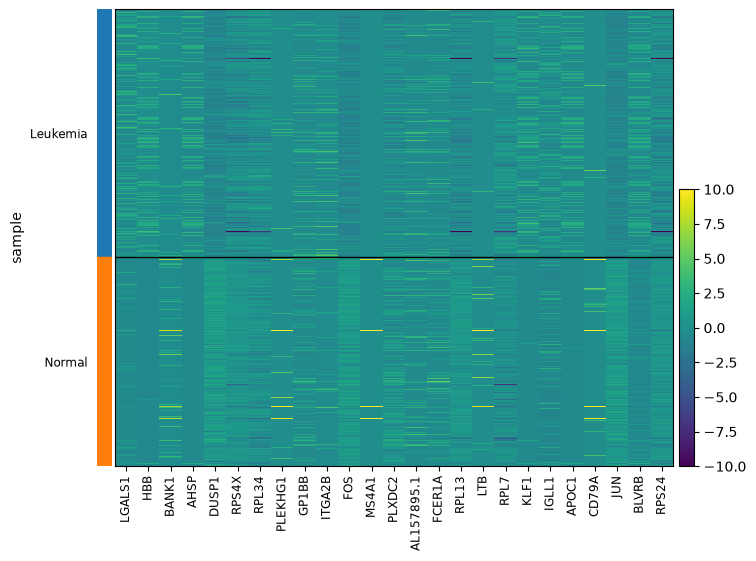

In [48]:
# Step 9: heatmap of top genes per PC (optional)
top_genes = set()
for idx in top_genes_idx:
    top_genes.update(adata_hvg.var_names[idx])
top_genes = list(top_genes)
sc.pl.heatmap(
    adata_hvg,
    var_names=top_genes,
    groupby="sample",
    use_raw=False,
    show_gene_labels=True
)

In [49]:
# Compute the neighborhood graph
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)

In [50]:
# Step 2: Inspect the distance matrix
dist_matrix = adata_hvg.obsp["distances"].toarray()  # convert sparse matrix to dense
dist_matrix.shape  # should be (n_cells, n_cells)

(1643, 1643)

In [51]:
# Ignore diagonal (distance of a cell to itself)
np.fill_diagonal(dist_matrix, np.nan)

# Maximum distance
max_dist = np.nanmax(dist_matrix)
max_idx = np.unravel_index(np.nanargmax(dist_matrix), dist_matrix.shape)

print(f"Max distance: {max_dist}")
print(f"Between cells: {adata_hvg.obs_names[max_idx[0]]} and {adata_hvg.obs_names[max_idx[1]]}")

Max distance: 144.82696533203125
Between cells: Normal_CATCGGGAGGACGAAA-1 and Normal_CGCCAAGTCATAGCAC-1


In [52]:
# Minimum distance (closest neighbors)
min_dist = np.nanmin(dist_matrix)
min_idx = np.unravel_index(np.nanargmin(dist_matrix), dist_matrix.shape)

print(f"Min distance: {min_dist}")
print(f"Between cells: {adata_hvg.obs_names[min_idx[0]]} and {adata_hvg.obs_names[min_idx[1]]}")

Min distance: 0.0
Between cells: Normal_AAACCTGAGGACCACA-1 and Normal_AAACCTGGTTTGGGCC-1


In [53]:
# Compute UMAP embedding from the neighborhood graph
sc.tl.umap(adata_hvg, min_dist=0.3, spread=1.0)

In [54]:
# UMAP coordinates (2D embedding)
umap_df = pd.DataFrame(
    adata_hvg.obsm["X_umap"],
    index=adata_hvg.obs_names,
    columns=["UMAP1", "UMAP2"]
)

umap_df.head()

,UMAP1,UMAP2
Normal_AAACCTGAGGACCACA-1,10.650701,4.373715
Normal_AAACCTGGTTTGGGCC-1,10.889911,7.734537
Normal_AAACGGGAGCAATATG-1,4.456213,4.080796
Normal_AAACGGGCATGTCTCC-1,11.369093,7.030703
Normal_AAACGGGTCGCGCCAA-1,10.312570,9.118420


In [ ]:
umap_df.to_csv("result_datasets/UMAP_embeddings_cells.csv")

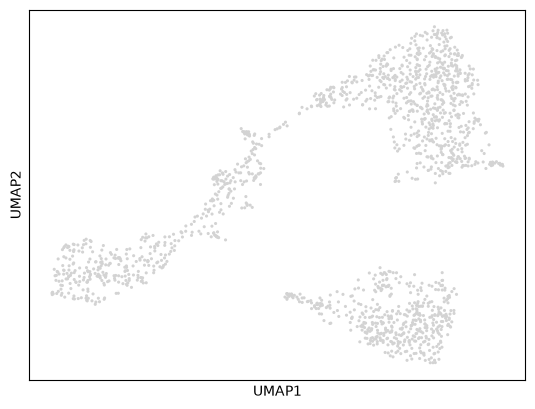

In [56]:
# Plain UMAP (structure only)
sc.pl.umap(
    adata_hvg,
    size=20
)

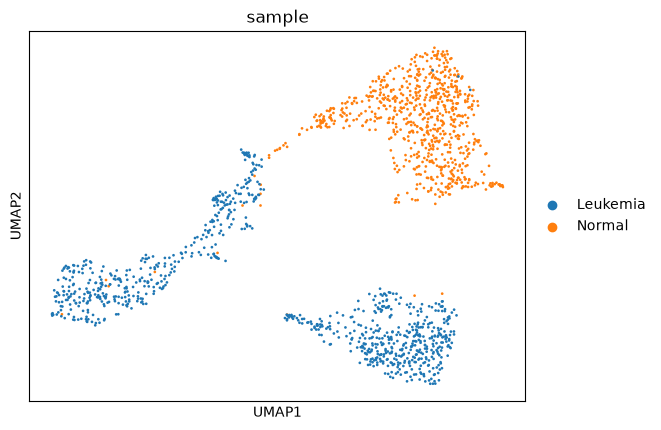

In [57]:
# UMAP colored by sample identity
sc.pl.umap(adata_hvg, color="sample", size=15)

In [58]:
import leidenalg

In [59]:
# Run Leiden clustering on the neighbor graph
sc.tl.leiden(
    adata_hvg,
    resolution=0.3,
    key_added="leiden_0.3"
)

C:\Users\PMLS\AppData\Local\Temp\ipykernel_60496\3900215484.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


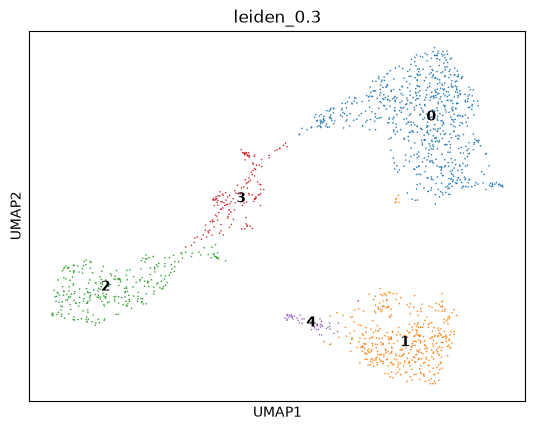

In [60]:
# Visualize UMAP colored by Leiden clusters
sc.pl.umap(
    adata_hvg,
    color="leiden_0.3",
    legend_loc="on data",
    size=5
)

In [61]:
# Run Leiden clustering at multiple resolutions
for res in [0.2, 0.3, 0.4, 0.6]:
    sc.tl.leiden(adata_hvg, resolution=res, key_added=f"leiden_{res}")

C:\Users\PMLS\AppData\Local\Temp\ipykernel_60496\1085296403.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hvg, resolution=res, key_added=f"leiden_{res}")


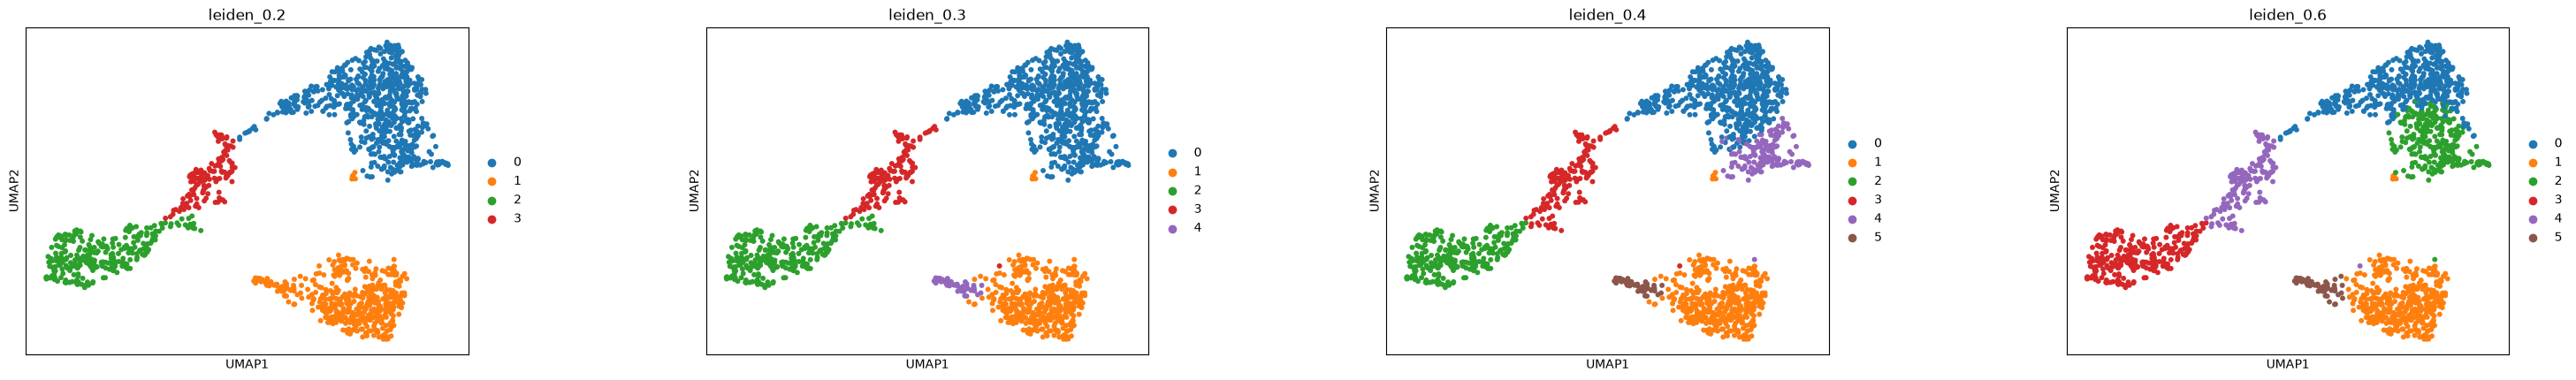

In [62]:
# Visualize UMAP colored by Leiden clusters at multiple resolutions
sc.pl.umap(adata_hvg, color=["leiden_0.2","leiden_0.3","leiden_0.4","leiden_0.6"], wspace=0.4)

In [63]:
# Check the number of clusters at each resolution
adata_hvg.obs["leiden_0.3"].value_counts()

leiden_0.3
0    728
1    423
2    287
3    155
4     50
Name: count, dtype: int64

In [ ]:
# Export cluster assignments to CSV
adata_hvg.obs["leiden_0.3"].value_counts().to_csv(
    "result_datasets/Cluster_Cell_Counts.csv"
)

In [ ]:
cluster_df = adata_hvg.obs[["sample", "leiden_0.3"]]
cluster_df.to_csv("result_datasets/Cell_Clusters_Leiden_0.3.csv")
cluster_df.head()

,sample,leiden_0.3
Normal_AAACCTGAGGACCACA-1,Normal,0
Normal_AAACCTGGTTTGGGCC-1,Normal,0
Normal_AAACGGGAGCAATATG-1,Normal,3
Normal_AAACGGGCATGTCTCC-1,Normal,0
Normal_AAACGGGTCGCGCCAA-1,Normal,0


In [66]:
# Marker genes per cluster
adata_filtered.obs["leiden_0.3"] = adata_hvg.obs["leiden_0.3"]

In [67]:
# View the first few rows
adata_filtered.obs["leiden_0.3"].head()

Normal_AAACCTGAGGACCACA-1    0
Normal_AAACCTGGTTTGGGCC-1    0
Normal_AAACGGGAGCAATATG-1    3
Normal_AAACGGGCATGTCTCC-1    0
Normal_AAACGGGTCGCGCCAA-1    0
Name: leiden_0.3, dtype: category
Categories (5, str): ['0', '1', '2', '3', '4']

In [68]:
# Marker genes for Leiden clusters at resolution 0.3
sc.tl.rank_genes_groups(
    adata_filtered, groupby="leiden_0.3", method="wilcoxon",
    layer="lognorm", pts=True, use_raw=False
)

In [ ]:
# Export all marker genes for all clusters to CSV
marker_df = sc.get.rank_genes_groups_df(adata_filtered, group=None)
marker_df.to_csv("result_datasets/Cluster_Marker_Genes.csv", index=False)
marker_df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,JUN,29.850847,3.782158,8.559391e-196,6.265645e-192,0.960165,0.369399
1,0,FOS,29.775320,3.444722,8.155168e-195,4.974788e-191,0.973901,0.555191
2,0,TPT1,29.598412,0.953926,1.566305e-192,8.189759e-189,1.000000,0.994536
3,0,DUSP1,29.232502,3.207165,7.494447e-188,3.428803e-184,0.958791,0.525683
4,0,EEF1A1,25.617695,0.521057,9.690151e-145,2.955577e-141,1.000000,0.998907


In [ ]:
# Define thresholds
LOGFC_CUTOFF = 1
PVALUE_CUTOFF = 0.05
PCT_GROUP_CUTOFF = 0.25
PCT_REF_CUTOFF = 0.25

# Extract the marker table
deg_df = sc.get.rank_genes_groups_df(
    adata_filtered,
    group=None
)

# Apply all gold-standard filters
filtered_deg_df = deg_df[
    (deg_df["pvals_adj"] <= PVALUE_CUTOFF) &
    ((deg_df["logfoldchanges"] >= LOGFC_CUTOFF) |
     (deg_df["logfoldchanges"] <= -LOGFC_CUTOFF)) &
    (deg_df["pct_nz_group"] >= PCT_GROUP_CUTOFF) &
    (deg_df["pct_nz_reference"] <= PCT_REF_CUTOFF)
].copy()

# Save refined markers
filtered_deg_df.to_csv("result_datasets/Refined_Marker_Genes_GoldStandard.csv", index=False)

# View top markers
for cluster in filtered_deg_df["group"].unique():
    print(f"\nCluster {cluster} top markers:")
    display(filtered_deg_df[filtered_deg_df["group"]==cluster].head(5))


Cluster 0 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
6,0,HLA-DRB5,24.940153,3.220349,2.730968e-137,7.139725e-134,0.822802,0.244809
39,0,AJ009632.2,17.623182,2.437535,1.635403e-69,8.430617e-67,0.674451,0.220765
60,0,AC011139.1,15.650803,5.726712,3.280537e-55,1.165737e-52,0.464286,0.021858
65,0,AL691403.1,15.182936,2.178860,4.587779e-52,1.423028e-49,0.609890,0.220765
72,0,TLE4,14.520626,3.241877,8.968739e-48,2.378731e-45,0.479396,0.073224



Cluster 1 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
36604,1,SOCS3,20.013933,4.400614,4.164570e-89,3.810686e-85,0.702128,0.077049
36622,1,CACNB2,16.875383,2.754686,6.828020e-64,9.612013e-61,0.690307,0.205738
36627,1,BAALC,16.194868,2.844622,5.481452e-59,6.471827e-56,0.638298,0.153279
36647,1,LGALS1,12.996081,2.258346,1.287747e-38,8.416576e-36,0.591017,0.174590
36649,1,PRKG1,12.621751,1.987940,1.602194e-36,9.939303e-34,0.602837,0.218033



Cluster 2 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
73203,2,APOC1,25.980648,7.677627,8.194856e-149,1.499700e-144,0.979094,0.047198
73208,2,AHSP,24.503689,8.374687,1.349314e-132,5.487360e-129,0.926829,0.054572
73209,2,HBA1,24.166786,7.220700,4.974065e-129,1.517131e-125,0.919861,0.091445
73210,2,KLF1,24.016069,5.613991,1.889405e-127,5.319548e-124,0.919861,0.061947
73211,2,FAM178B,23.948141,7.910692,9.661492e-127,2.525859e-123,0.902439,0.017699



Cluster 3 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
109805,3,ITGA2B,15.909645,5.020776,5.432064e-57,6.627299e-53,0.812903,0.080645
109806,3,FCER1A,14.199506,3.272302,9.226015e-46,6.753628e-42,0.845161,0.182796
109809,3,PLEK,13.270520,3.580097,3.431908e-40,1.570141e-36,0.761290,0.209005
109812,3,AL157895.1,12.672070,3.615981,8.445663e-37,2.810179e-33,0.716129,0.133737
109819,3,FREM1,11.373588,2.628145,5.661173e-30,9.008896e-27,0.722581,0.223118



Cluster 4 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
146404,4,AZU1,11.037922,8.831928,2.507659e-28,9.178284e-24,0.92,0.015694
146405,4,CFD,10.619254,5.891488,2.424898e-26,4.437685e-22,0.90,0.064658
146407,4,MPO,10.372837,6.821305,3.295909e-25,3.015839e-21,0.88,0.051475
146415,4,PRTN3,8.864969,9.406528,7.652531e-19,2.334086e-15,0.74,0.013183
146434,4,ELANE,7.215123,9.680944,5.388510e-13,6.163277e-10,0.60,0.001883


In [ ]:
# save refined markers
filtered_deg_df.to_csv("result_datasets/Refined_Marker_Genes.csv", index=False)

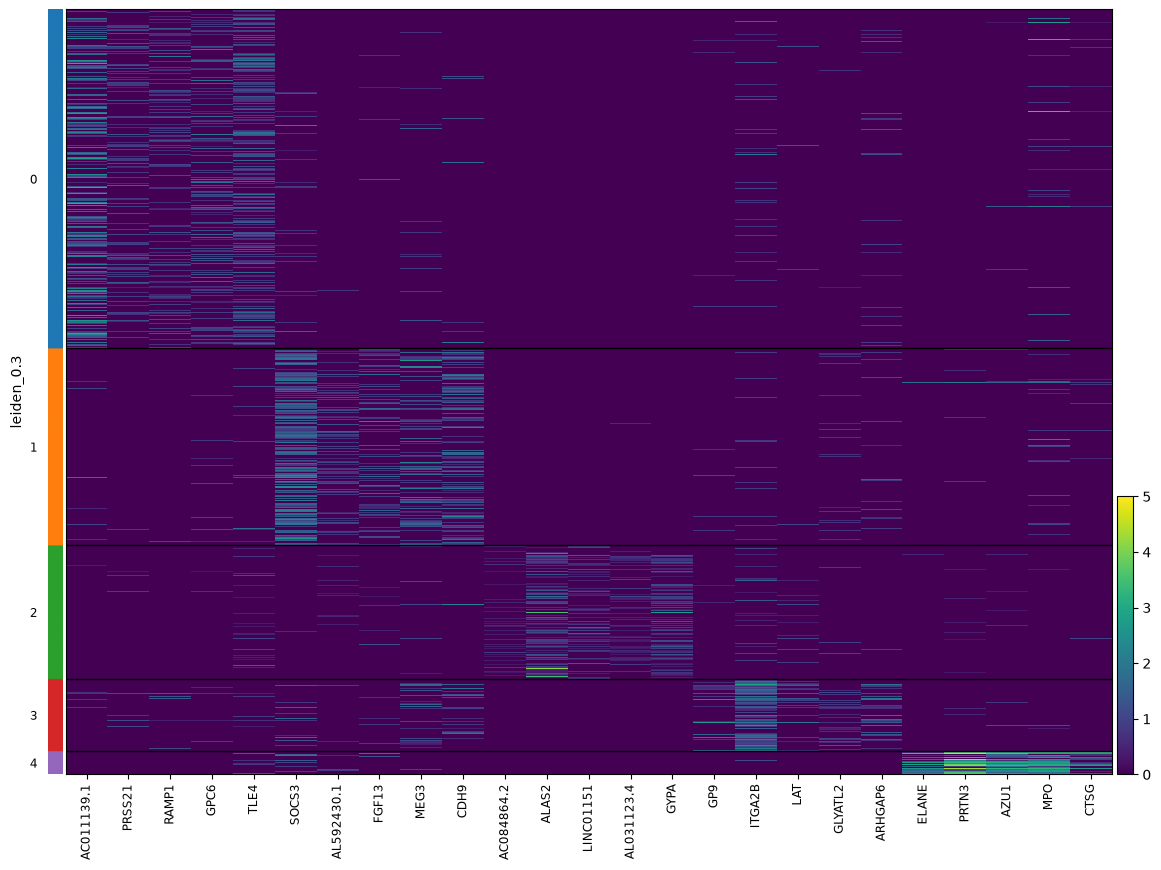

In [72]:
# Select top 5 markers per cluster
top_n = 5
top_markers = (
    filtered_deg_df.groupby("group")
    .apply(lambda x: x.nlargest(top_n, "logfoldchanges"))
    .reset_index(drop=True)
)

# Extract gene names
genes_to_plot = top_markers["names"].unique().tolist()

# Heatmap using Scanpy
sc.pl.heatmap(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.3",
    use_raw=False,       # uses lognorm layer
    layer="lognorm",
    swap_axes=False,     # clusters on y-axis, genes on x-axis
    cmap="viridis",
    show_gene_labels=True,
    figsize=(14,10)
)

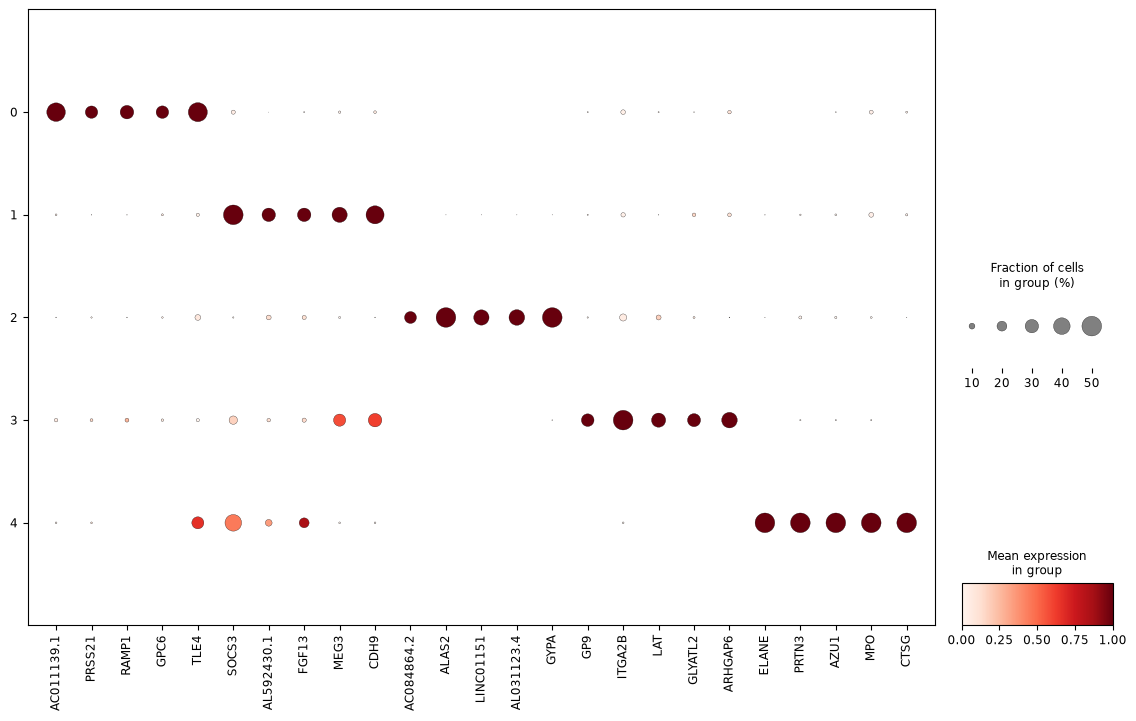

In [73]:
# Dotplot using Scanpy
sc.pl.dotplot(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.3",
    use_raw=False,
    layer="lognorm",
    standard_scale="var",  # scales each gene to [0,1] for comparability
    dot_max=0.5,
    figsize=(14,8)
)

In [74]:
import celltypist
from celltypist import models

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [75]:
# Show all available models (locally downloaded or from remote index)
model_list_df = models.models_description(on_the_fly=True)

print(model_list_df)

👉 Detailed model information can be found at `https://www.celltypist.org/models`


                                      model  \
0                 Adult_cHSPCs_Illumina.pkl   
1                   Adult_cHSPCs_Ultima.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
..                                      ...   
56                   Nuclei_Lung_Airway.pkl   
57       PaediatricAdult_COVID19_Airway.pkl   
58         PaediatricAdult_COVID19_PBMC.pkl   
59                      Pan_Fetal_Human.pkl   
60                Thymus_Allograft_PBMC.pkl   

                                          description  
0   human circulating hematopoietic stem and proge...  
1   human circulating hematopoietic stem and proge...  
2   peripheral blood mononuclear cell types from C...  
3   cell types from the hippocampus of adult cynom...  
4   cell types and subtypes (10x-based) from the a...  
..                                                ...  
56  cell populations from snRNA-seq of five

In [76]:
adata_filtered

AnnData object with n_obs × n_vars = 1643 × 36601
    obs: 'sample', 'sample_id', 'SampleName', 'type', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.3'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.3_colors'
    layers: None (.X), 'lognorm'

In [77]:
# Make a copy of your filtered AnnData
adata_ct = adata_filtered.copy()

In [78]:
# Use the log-normalized data for CellTypist
adata_ct.X = adata_filtered.layers["lognorm"]

In [79]:
adata_ct.shape

(1643, 36601)

In [80]:
from celltypist import models, annotate

In [81]:
# Model description
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [ ]:
# Load the model
model = models.Model.load("Immune_All_Low.pkl")

In [83]:
# Run annotation with majority voting
predictions = annotate(adata_ct, model=model, majority_voting=True)

🔬 Input data has 1643 cells and 36601 genes
🔗 Matching reference genes in the model
🧬 6147 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [84]:
predictions

CellTypist prediction result for 1643 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 1643 query cells and 98 cell types
    probability_matrix: data frame with 1643 query cells and 98 cell types
    adata: AnnData object referred

In [85]:
predictions.adata.obs.shape

(1643, 16)

In [86]:
# Check the predicted labels
predictions.predicted_labels.majority_voting.value_counts()

majority_voting
HSC/MPP                                         1105
Mid erythroid                                    177
Early erythroid                                  123
Megakaryocyte precursor                           94
CMP                                               53
Early MK                                          50
Mast cells                                        21
Megakaryocyte-erythroid-mast cell progenitor      20
Name: count, dtype: int64

In [87]:
# Remove duplicated indices (if any) from predicted labels
predicted_labels_clean = predictions.predicted_labels[predictions.predicted_labels.index.duplicated(keep='first') == False]

print(predicted_labels_clean.shape)
print(predicted_labels_clean.index.duplicated().sum())

(1643, 3)
0


In [88]:
# Map the predicted labels back to the original AnnData object
adata_ct.obs["celltypist_majority"] = adata_ct.obs_names.map(
    predictions.predicted_labels["majority_voting"]
)

In [89]:
# Check the distribution of predicted labels in the original AnnData object
adata_ct.obs["celltypist_majority"].value_counts(dropna=False)

celltypist_majority
HSC/MPP                                         1105
Mid erythroid                                    177
Early erythroid                                  123
Megakaryocyte precursor                           94
CMP                                               53
Early MK                                          50
Mast cells                                        21
Megakaryocyte-erythroid-mast cell progenitor      20
Name: count, dtype: int64

In [90]:
adata_ct

AnnData object with n_obs × n_vars = 1643 × 36601
    obs: 'sample', 'sample_id', 'SampleName', 'type', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.3', 'celltypist_majority'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.3_colors', 'neighbors', 'over_clustering'
    obsm: 'X_pca'
    obsp: 'connectivities', 'distances'
    layers: None (.X), 'lognorm'

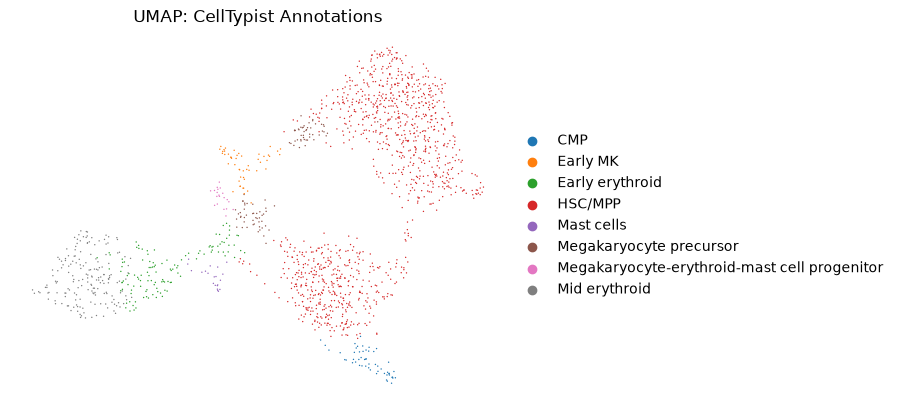

In [91]:
# Compute UMAP if not already done
if 'X_umap' not in adata_ct.obsm:
    sc.tl.umap(adata_ct)

# Plot UMAP with legend outside
sc.pl.umap(
    adata_ct,
    color='celltypist_majority',
    legend_loc='right margin',  # place legend outside
    title='UMAP: CellTypist Annotations',
    frameon=False,              # removes frame for cleaner view
    size=4                     # adjust dot size
)

In [92]:
# Cross-tabulation of clusters vs CellTypist labels
pd.crosstab(adata_ct.obs["leiden_0.3"], adata_ct.obs["celltypist_majority"])

celltypist_majority,CMP,Early MK,Early erythroid,HSC/MPP,Mast cells,Megakaryocyte precursor,Megakaryocyte-erythroid-mast cell progenitor,Mid erythroid
leiden_0.3,,,,,,,,
0,0,2,0,678,0,48,0,0
1,4,0,0,418,0,1,0,0
2,0,0,89,0,21,0,0,177
3,0,48,34,8,0,45,20,0
4,49,0,0,1,0,0,0,0


In [ ]:
# Select relevant columns
student_csv = adata_ct.obs[['sample', 'sample_id', 'leiden_0.3', 'celltypist_majority']]

# Save
student_csv.to_csv("result_datasets/Annotated_Cells_UMAP.csv")

In [ ]:
# Output directory for DEGs
output_dir = "//wsl.localhost/Ubuntu/home/aaslam123/SummerSchool2026/Module2/Project_scRNA+Report/DEGs_by_celltype"
os.makedirs(output_dir, exist_ok=True)

In [95]:
reference_sample = "Normal"

In [96]:
# Volcano plot thresholds
padj_thresh = 0.05
logfc_thresh = 1

In [97]:
# List all unique cell types
cell_types = adata_ct.obs['celltypist_majority'].unique()
print("Cell types found:", cell_types)

Cell types found: ['HSC/MPP', 'Megakaryocyte-erythroid-mast cell progenitor', 'Megakaryocyte precursor', 'Early MK', 'Early erythroid', 'Mid erythroid', 'CMP', 'Mast cells']
Categories (8, str): ['CMP', 'Early MK', 'Early erythroid', 'HSC/MPP', 'Mast cells', 'Megakaryocyte precursor', 'Megakaryocyte-erythroid-mast cell progenitor', 'Mid erythroid']


In [ ]:
for cell in cell_types:
    adata_cell = adata_ct[adata_ct.obs["celltypist_majority"] == cell].copy()
    counts = adata_cell.obs["sample"].value_counts()
    print(f"\n{cell}: {dict(counts)}")

    if counts.min() < 10 or len(counts) < 2:
        print(f"  Skipping {cell} — insufficient cells in one condition")
        continue

    sc.tl.rank_genes_groups(
        adata_cell, groupby="sample", reference=reference_sample,
        method="wilcoxon", layer="lognorm", pts=True, use_raw=False
    )
    degs = sc.get.rank_genes_groups_df(adata_cell, group=None)
    degs["Significant"] = np.where(
        (degs["pvals_adj"] <= padj_thresh) & (degs["logfoldchanges"].abs() >= logfc_thresh),
        "Significant", "Not Sig"
    )

    # Sanitize ONCE, reuse everywhere — this is the fix
    safe_name = cell.replace(" ", "_").replace("/", "-")
    cell_folder = os.path.join(output_dir, safe_name)
    os.makedirs(cell_folder, exist_ok=True)

    degs.to_csv(os.path.join(cell_folder, f"{safe_name}_all_DEGs.csv"), index=False)
    degs[degs["Significant"]=="Significant"].to_csv(
        os.path.join(cell_folder, f"{safe_name}_significant_DEGs.csv"), index=False
    )

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=degs, x="logfoldchanges", y=-np.log10(degs["pvals_adj"]+1e-300),
                     hue="Significant", palette={"Not Sig":"gray","Significant":"red"}, alpha=0.7)
    plt.axvline(logfc_thresh, ls="--", c="blue"); plt.axvline(-logfc_thresh, ls="--", c="blue")
    plt.axhline(-np.log10(padj_thresh), ls="--", c="green")
    plt.title(f"Volcano: {cell} (Leukemia vs Normal)")
    plt.tight_layout()
    plt.savefig(os.path.join(cell_folder, f"{safe_name}_volcano.png"), dpi=300)
    plt.close()


HSC/MPP: {'Normal': np.int64(683), 'Leukemia': np.int64(422)}

Megakaryocyte-erythroid-mast cell progenitor: {'Leukemia': np.int64(16), 'Normal': np.int64(4)}
  Skipping Megakaryocyte-erythroid-mast cell progenitor — insufficient cells in one condition

Megakaryocyte precursor: {'Normal': np.int64(48), 'Leukemia': np.int64(46)}

Early MK: {'Leukemia': np.int64(38), 'Normal': np.int64(12)}

Early erythroid: {'Leukemia': np.int64(121), 'Normal': np.int64(2)}
  Skipping Early erythroid — insufficient cells in one condition

Mid erythroid: {'Leukemia': np.int64(175), 'Normal': np.int64(2)}
  Skipping Mid erythroid — insufficient cells in one condition

CMP: {'Leukemia': np.int64(52), 'Normal': np.int64(1)}
  Skipping CMP — insufficient cells in one condition

Mast cells: {'Leukemia': np.int64(20), 'Normal': np.int64(1)}
  Skipping Mast cells — insufficient cells in one condition
